# Overnight Session — Signal Research

**Instrument:** SPY (5-min bars, extended hours)
**Signal:** If today's market return < 0, go long overnight (close → next open)
**Exit:** Next day pre-market open
**No stop loss** — holds overnight unconditionally.
**Long-only** — short side shown to be unprofitable.

This notebook generates raw signal trades — **no position sizing, no equity tracking.**

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees_pct
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Configuration

In [2]:
SYMBOL     = "SPY"
INSTRUMENT = "SPY"
START_DATE = "2016-01-01"
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000
STRATEGY_NAME    = "Overnight"
SAVE_NAME        = "overnight" 

## 3. Data Fetching & Session Decomposition

In [3]:
data_dict = fetch_historical_data(
    [SYMBOL], TimeFrame(5, TimeFrameUnit.Minute), START_DATE, END_DATE)
df = data_dict[SYMBOL].copy()
df = df.reset_index()
df["timestamp"] = pd.to_datetime(df["timestamp"])
if df["timestamp"].dt.tz is not None:
    df["timestamp"] = df["timestamp"].dt.tz_convert("US/Eastern")
else:
    df["timestamp"] = df["timestamp"].dt.tz_localize("UTC").tz_convert("US/Eastern")
df = df.set_index("timestamp")

print(f"Total bars: {len(df):,}")

Fetching SPY...
  472,076 bars
Total bars: 472,076


In [4]:
def assign_session(ts):
    t = ts.time()
    if time(4, 0) <= t <= time(9, 25):
        return "pre_market"
    elif time(9, 30) <= t <= time(15, 55):
        return "market"
    elif time(16, 0) <= t <= time(19, 55):
        return "after_market"
    return None

df["session"] = df.index.map(assign_session)
df["session_date"] = df.index.date
df = df.dropna(subset=["session"]).copy()

print(f"Bars with sessions: {len(df):,}")
print(df["session"].value_counts())

Bars with sessions: 472,039
session
market          200793
pre_market      160102
after_market    111144
Name: count, dtype: int64


In [5]:
# Per-session OHLC
session_ohlc = df.groupby(["session_date", "session"]).agg(
    session_open=("open", "first"),
    session_close=("close", "last"),
).reset_index()

session_order = ["pre_market", "market", "after_market"]
session_ohlc["session"] = pd.Categorical(session_ohlc["session"], categories=session_order, ordered=True)
session_ohlc = session_ohlc.sort_values(["session_date", "session"]).reset_index(drop=True)

session_counts = session_ohlc.groupby("session_date")["session"].count()
valid_dates = session_counts[session_counts == 3].index
session_ohlc = session_ohlc[session_ohlc["session_date"].isin(valid_dates)].reset_index(drop=True)

print(f"Complete days: {len(valid_dates)}")

Complete days: 2575


In [6]:
# Build overnight: after-market close → next day pre-market open
pivot = session_ohlc.pivot(index="session_date", columns="session",
                           values=["session_open", "session_close"])
pivot.columns = ["_".join(col) for col in pivot.columns.values]
pivot = pivot.reset_index()

pivot["overnight_open"] = pivot["session_close_after_market"]
pivot["overnight_close"] = pivot["session_open_pre_market"].shift(-1)
pivot = pivot.dropna(subset=["overnight_close"]).copy()

pivot["market_return"] = (pivot["session_close_market"] - pivot["session_open_market"]) / pivot["session_open_market"]
pivot["overnight_return"] = (pivot["overnight_close"] - pivot["overnight_open"]) / pivot["overnight_open"]

print(f"Days with overnight data: {len(pivot)}")

Days with overnight data: 2574


## 4. Signal Generation

In [7]:
def generate_signals(pivot_df):
    """
    Generate raw overnight trades — signal only, no sizing.

    Signal: if today's market return < 0, go long overnight.
    Long-only (short side is unprofitable).

    Returns DataFrame with standardized columns.
    """
    trades = []

    for _, row in pivot_df.iterrows():
        if row["market_return"] >= 0:
            continue  # long-only: skip positive market days

        entry_price = row["overnight_open"]
        exit_price = row["overnight_close"]
        pct_ret = (exit_price - entry_price) / entry_price

        entry_date = row["session_date"]
        exit_date = pd.Timestamp(entry_date) + pd.offsets.BDay(1)

        trades.append({
            "entry_time":      pd.Timestamp(entry_date).replace(hour=15, minute=55),
            "exit_time":       exit_date.replace(hour=9, minute=30),
            "direction":       "long",
            "instrument":      INSTRUMENT,
            "entry_price":     round(entry_price, 4),
            "exit_price":      round(exit_price, 4),
            "pct_return_gross": round(pct_ret, 6),
            "exit_reason":     "overnight_close",
            "stop_price":      np.nan,
        })

    return pd.DataFrame(trades)

print("generate_signals() defined.")

generate_signals() defined.


## 5. Signal Generation & Significance

In [8]:
raw_trades = generate_signals(pivot)
print(f"Total signal trades: {len(raw_trades)}")
print(f"All long: {(raw_trades['direction'] == 'long').all()}")

# Net returns
raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"Avg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# Significance: GROSS
sig_gross = raw_trades[["direction", "pct_return_gross"]].copy()
sig_gross["net_pnl"] = sig_gross["pct_return_gross"]
sig_gross["equity_before"] = 1.0
sig_gross["position"] = sig_gross["direction"]

if len(sig_gross) >= 5:
    report_gross = full_significance_report(sig_gross, strategy_name=f"{STRATEGY_NAME} (gross)")
    print_significance_report(report_gross)

# Significance: NET
sig_net = raw_trades[["direction", "pct_return_net"]].copy()
sig_net["net_pnl"] = sig_net["pct_return_net"]
sig_net["equity_before"] = 1.0
sig_net["position"] = sig_net["direction"]

if len(sig_net) >= 5:
    report_net = full_significance_report(sig_net, strategy_name=f"{STRATEGY_NAME} (net)")
    print_significance_report(report_net)

Total signal trades: 1177
All long: True
Avg fee: 0.0093% per trade
Avg gross return: 0.0448%
Avg net return: 0.0355%

STATISTICAL SIGNIFICANCE — Overnight (gross)

1. t-test (returns > 0)
   Mean return:  0.0448% per trade
   t-statistic:  3.1715
   p-value:      0.000778
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   1.4681
   95% CI:            [0.5687, 2.4218]
   % below zero:      0.12%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   1.4681
   p-value:           0.0005
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)

STATISTICAL SIGNIFICANCE — Overnight (net)

1. t-test (returns > 0)
   Mean return:  0.0355% per trade
   t-statistic:  2.5158
   p-value:      0.006004
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   1.1646
   95% CI:            [0.2714, 2.1052]
   % below zero:      0.64%
   Significan

## 6. Simple Equity Curve — Gross vs Net

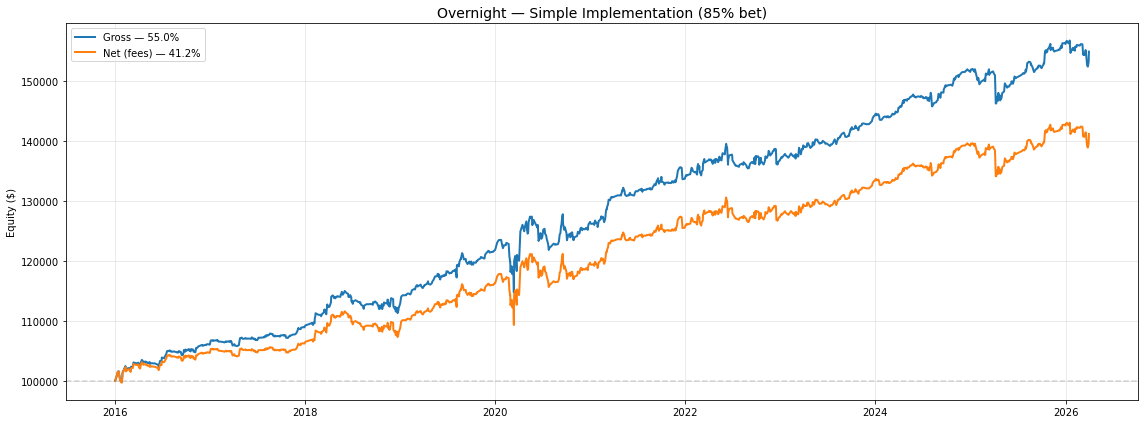

Fee drag: $13,746


In [9]:
BET_SIZE = 0.85

equity_gross = STARTING_CAPITAL
equity_net = STARTING_CAPITAL
gross_curve = [STARTING_CAPITAL]
net_curve = [STARTING_CAPITAL]

for _, trade in raw_trades.iterrows():
    shares_g = int(equity_gross * BET_SIZE / trade["entry_price"])
    shares_n = int(equity_net * BET_SIZE / trade["entry_price"])

    pnl_g = shares_g * (trade["exit_price"] - trade["entry_price"])
    pnl_n = shares_n * (trade["exit_price"] - trade["entry_price"])

    from _shared.fees import calculate_fees
    fees = calculate_fees(shares_n, trade["entry_price"], trade["exit_price"], trade["direction"])

    equity_gross += pnl_g
    equity_net += pnl_n - fees
    gross_curve.append(equity_gross)
    net_curve.append(equity_net)

dates = [pd.Timestamp(START_DATE)] + pd.to_datetime(raw_trades["exit_time"]).dt.tz_localize(None).tolist()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dates, gross_curve, linewidth=2, label=f"Gross — {(gross_curve[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.plot(dates, net_curve, linewidth=2, label=f"Net (fees) — {(net_curve[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} — Simple Implementation ({BET_SIZE:.0%} bet)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Fee drag: ${gross_curve[-1] - net_curve[-1]:,.0f}")

## 7. Save Standardized Trades

In [10]:
import os, json

os.makedirs("results", exist_ok=True)

std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv("results/overnight_trades.csv", index=False)
print(f"Saved {len(raw_trades)} standardized trades → results/overnight_trades.csv")

summary = {
    "strategy":    STRATEGY_NAME,
    "instrument":  INSTRUMENT,
    "portfolio":   "short_term",
    "period":      f"{START_DATE} → {END_DATE}",
    "params":      {"signal": "market_return < 0", "direction": "long_only"},
    "trades":      len(raw_trades),
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"],
                  "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"],
                  "tests_passed": report_net["tests_passed"]},
    },
}
with open("results/overnight_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved summary → results/overnight_summary.json")
print(f"\nNext: run Overnight_Implementation.ipynb for sizing comparison")

Saved 1177 standardized trades → results/overnight_trades.csv
Saved summary → results/overnight_summary.json

Next: run Overnight_Implementation.ipynb for sizing comparison
